# Tokopedia Data Analyzer

Notebook analisis data hasil scraping Tokopedia.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path.cwd()
csv_candidates = [
    DATA_DIR / "tokopedia_results.csv",
    DATA_DIR / "belajarDataMining" / "tokopedia_results.csv",
    *sorted(DATA_DIR.glob("tokopedia_results*.csv")),
    *sorted((DATA_DIR / "belajarDataMining").glob("tokopedia_results*.csv")),
]
csv_path = next((path for path in csv_candidates if path.exists()), None)
if csv_path is None:
    raise FileNotFoundError("CSV Tokopedia tidak ditemukan di folder notebook.")

df = pd.read_csv(csv_path)
required_columns = {"name", "price", "shop", "location"}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Kolom CSV kurang: {sorted(missing_columns)}")

# Membersihkan format harga seperti Rp63.000 menjadi angka 63000.
df["price"] = (
    df["price"].astype(str)
    .str.replace("Rp", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(int)
)

print(f"File: {csv_path.name}")
print(f"Jumlah produk: {len(df)}")
display(df.head())

File: tokopedia_results.csv
Jumlah produk: 200


,name,price,shop,location,rating,link
0,Mouse Logitech B100,63000,MULTIKOM ID,Palembang,0,https://www.tokopedia.com/multikom-id/mouse-lo...
1,Mouse Logitech Usb B100 Original,63000,MULTIKOM ID,Palembang,0,https://www.tokopedia.com/multikom-id/mouse-lo...
2,Logitech Mouse B100 - Original Garansi Resmi 3...,89000,Yolori,Jakarta Pusat,0,https://www.tokopedia.com/yolori/logitech-mous...
3,Logitech B100 Optical Mouse USB,65000,hans computer,Jakarta Pusat,0,https://www.tokopedia.com/hans-computer/logite...
4,Mouse Logitech B100 Original,66250,Shine Plaza,Bandung,0,https://www.tokopedia.com/shineplaza/mouse-log...


In [2]:
def show_product(product):
    print(f"Nama   : {product['name']}")
    print(f"Harga  : Rp{product['price']:,}".replace(',', '.'))
    print(f"Toko   : {product['shop']}")
    print(f"Kota   : {product['location']}")


def show_extreme(ascending=False):
    product = df.sort_values('price', ascending=ascending).iloc[0]
    show_product(product)


def search_products():
    keyword = input('Masukkan kata kunci nama produk: ').strip()
    results = df[df['name'].astype(str).str.contains(keyword, case=False, na=False)]
    if results.empty:
        print('Produk tidak ditemukan.')
        return
    print(f'{len(results)} produk ditemukan:')
    for _, product in results.iterrows():
        show_product(product)
        print('-' * 40)

In [3]:
def show_top_cities():
    city_counts = df['location'].fillna('Tidak diketahui').value_counts().head(5)
    print('Top 5 kota dengan produk terbanyak:')
    for city, count in city_counts.items():
        print(f'{city:25} {count:3} ' + '█' * min(count, 40))


def show_charts():
    cheapest = df.nsmallest(10, 'price').sort_values('price')
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].barh(cheapest['name'].str.slice(0, 35), cheapest['price'], color='teal')
    axes[0].set_title('10 Produk Termurah')
    axes[0].set_xlabel('Harga (Rupiah)')
    axes[0].invert_yaxis()
    df['price'].plot.hist(ax=axes[1], bins=10, color='darkorange', edgecolor='black')
    axes[1].set_title('Distribusi Harga')
    axes[1].set_xlabel('Harga (Rupiah)')
    plt.tight_layout()
    plt.show()


   TOKOPEDIA DATA ANALYZER
1. Produk termahal
2. Produk termurah
3. Rata-rata & median harga
4. Cari produk berdasarkan nama
5. Top 5 kota dengan produk terbanyak
6. Tampilkan grafik
0. Keluar
Nama   : (10PCS) Logitech Mouse Kabel B100 (10PCS)
Harga  : Rp580.000
Toko   : Aquarius Ofc
Kota   : Jakarta Barat

   TOKOPEDIA DATA ANALYZER
1. Produk termahal
2. Produk termurah
3. Rata-rata & median harga
4. Cari produk berdasarkan nama
5. Top 5 kota dengan produk terbanyak
6. Tampilkan grafik
0. Keluar
Rata-rata harga: Rp86.193
Median harga   : Rp67.000

   TOKOPEDIA DATA ANALYZER
1. Produk termahal
2. Produk termurah
3. Rata-rata & median harga
4. Cari produk berdasarkan nama
5. Top 5 kota dengan produk terbanyak
6. Tampilkan grafik
0. Keluar
22 produk ditemukan:
Nama   : Logitech Keyboard + Mouse B100 (K120 + B100) USB Resmi
Harga  : Rp183.000
Toko   : Pazcom
Kota   : Jakarta Pusat
----------------------------------------
Nama   : Logitech Keyboard K120 + Mouse Logitech B100 (USB) Combo S

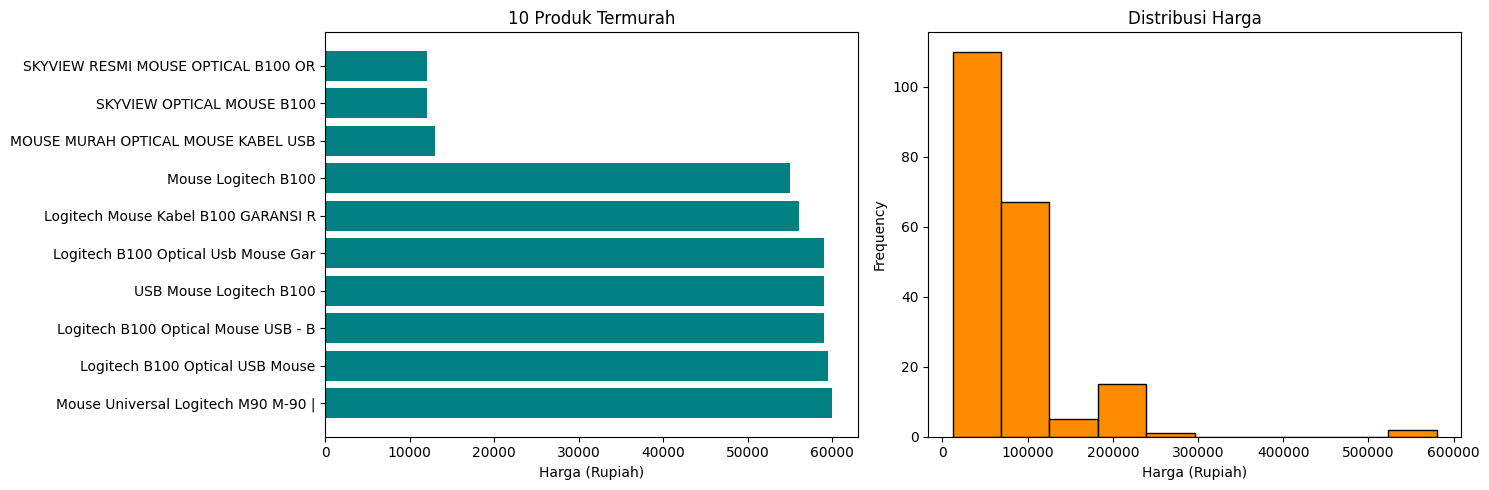


   TOKOPEDIA DATA ANALYZER
1. Produk termahal
2. Produk termurah
3. Rata-rata & median harga
4. Cari produk berdasarkan nama
5. Top 5 kota dengan produk terbanyak
6. Tampilkan grafik
0. Keluar
Program selesai.


In [5]:
def run_menu():
    while True:
        print('\n' + '=' * 40)
        print('   TOKOPEDIA DATA ANALYZER')
        print('=' * 40)
        print('1. Produk termahal')
        print('2. Produk termurah')
        print('3. Rata-rata & median harga')
        print('4. Cari produk berdasarkan nama')
        print('5. Top 5 kota dengan produk terbanyak')
        print('6. Tampilkan grafik')
        print('0. Keluar')
        choice = input('Pilih menu: ').strip()

        if choice == '1':
            show_extreme()
        elif choice == '2':
            show_extreme(ascending=True)
        elif choice == '3':
            print(f'Rata-rata harga: Rp{df["price"].mean():,.0f}'.replace(',', '.'))
            print(f'Median harga   : Rp{df["price"].median():,.0f}'.replace(',', '.'))
        elif choice == '4':
            search_products()
        elif choice == '5':
            show_top_cities()
        elif choice == '6':
            show_charts()
        elif choice == '0':
            print('Program selesai.')
            break
        else:
            print('Pilihan tidak valid.')

# Jalankan setelah semua cell sebelumnya selesai.
run_menu()